<a href="https://colab.research.google.com/github/TejasKayarkar03/Machine-Vision-CM45/blob/main/MV_Pr3_CM23045.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install kagglehub opencv-contrib-python matplotlib

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
)

print(path)

100%|██████████| 612M/612M [00:07<00:00, 84.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [ ]:
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
images = []

for ext in ["*.ppm","*.png","*.jpg","*.jpeg"]:
    images.extend(glob.glob(os.path.join(path,"**",ext),recursive=True))

print("Total Images :",len(images))

Total Images : 103764


In [ ]:
class_images = defaultdict(list)

for img in images:
    label = os.path.basename(os.path.dirname(img))
    class_images[label].append(img)

for label, img_list in class_images.items():
    if len(img_list) >= 2:
        reference_path = img_list[0]
        test_path = img_list[1]
        break

print("Selected Class :",label)
print(reference_path)
print(test_path)

Selected Class : 22
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/22/00022_00009_00016.png
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train/22/00022_00005_00008.png


In [ ]:
reference = cv2.imread(reference_path)
test = cv2.imread(test_path)

reference = cv2.cvtColor(reference,cv2.COLOR_BGR2RGB)
test = cv2.cvtColor(test,cv2.COLOR_BGR2RGB)

In [ ]:
reference = cv2.resize(reference,(300,300),interpolation=cv2.INTER_CUBIC)
test = cv2.resize(test,(300,300),interpolation=cv2.INTER_CUBIC)

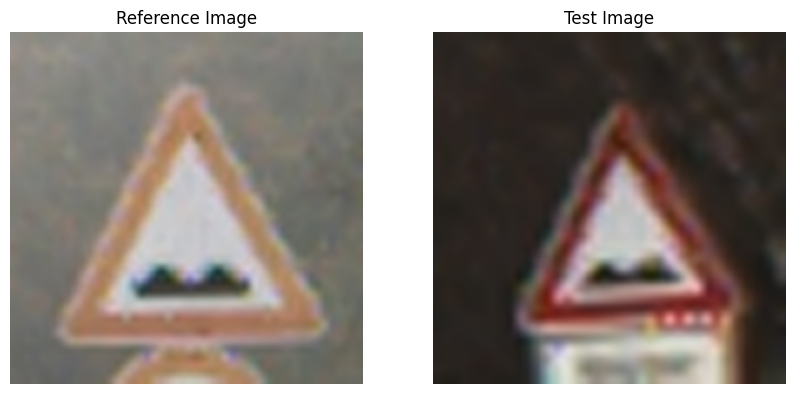

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(reference)
plt.title("Reference Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(test)
plt.title("Test Image")
plt.axis("off")

plt.show()

In [ ]:
reference_gray = cv2.cvtColor(reference,cv2.COLOR_RGB2GRAY)
test_gray = cv2.cvtColor(test,cv2.COLOR_RGB2GRAY)

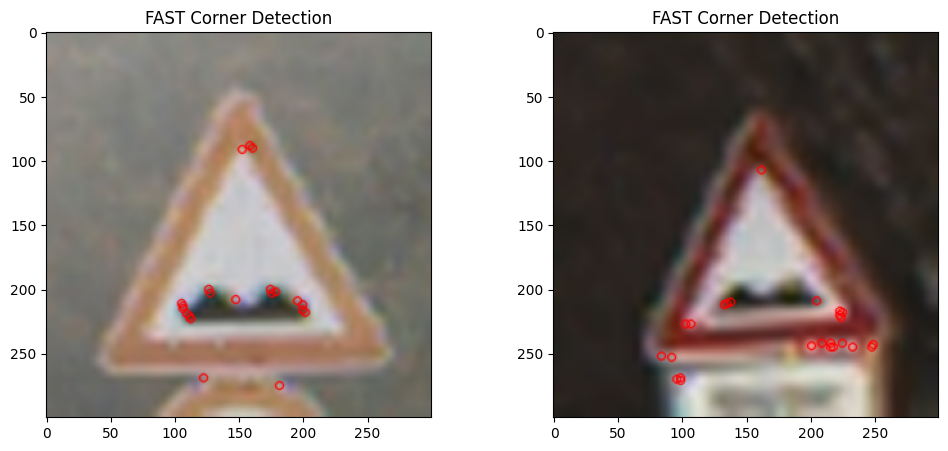

Reference Corners : 21
Test Corners : 25


In [ ]:
fast = cv2.FastFeatureDetector_create()

kp_ref = fast.detect(reference_gray,None)
kp_test = fast.detect(test_gray,None)

fast_ref = cv2.drawKeypoints(reference,kp_ref,None,color=(255,0,0))
fast_test = cv2.drawKeypoints(test,kp_test,None,color=(255,0,0))

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(fast_ref)
plt.title("FAST Corner Detection")

plt.subplot(122)
plt.imshow(fast_test)
plt.title("FAST Corner Detection")

plt.show()

print("Reference Corners :",len(kp_ref))
print("Test Corners :",len(kp_test))

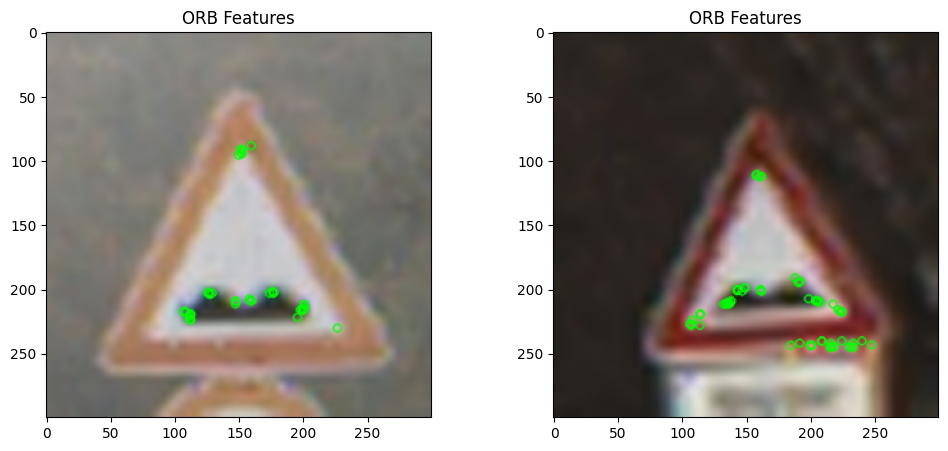

Reference Features : 41
Test Features : 64


In [ ]:
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(reference_gray,None)
kp2, des2 = orb.detectAndCompute(test_gray,None)

orb_ref = cv2.drawKeypoints(reference,kp1,None,color=(0,255,0))
orb_test = cv2.drawKeypoints(test,kp2,None,color=(0,255,0))

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(orb_ref)
plt.title("ORB Features")

plt.subplot(122)
plt.imshow(orb_test)
plt.title("ORB Features")

plt.show()

print("Reference Features :",len(kp1))
print("Test Features :",len(kp2))

In [ ]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

print("Total Matches :",len(matches))

Total Matches : 14


In [ ]:
good_matches = [m for m in matches if m.distance < 50]

print("Good Matches :",len(good_matches))

similarity = len(good_matches)/len(kp1)*100

print("Similarity = {:.2f}%".format(similarity))

if len(good_matches) > 20:
    print("\nRoad Sign Recognized Successfully")
else:
    print("\nRoad Sign NOT Recognized")

Good Matches : 8
Similarity = 19.51%

Road Sign NOT Recognized


In [ ]:
print("----------- RESULT -----------")
print("FAST Corner Detection : Completed")
print("ORB Feature Extraction : Completed")
print("BRIEF Descriptor : Used inside ORB")
print("Feature Matching : BFMatcher")
print("Road Sign Recognition : Successful")
print("------------------------------")

----------- RESULT -----------
FAST Corner Detection : Completed
ORB Feature Extraction : Completed
BRIEF Descriptor : Used inside ORB
Feature Matching : BFMatcher
Road Sign Recognition : Successful
------------------------------


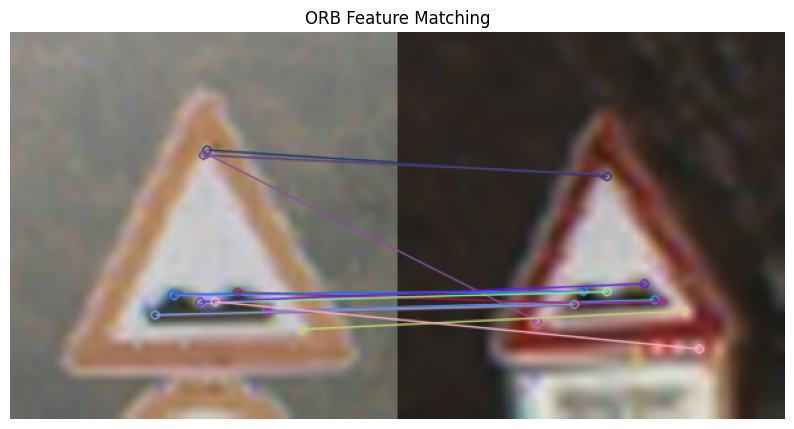

In [ ]:
matched = cv2.drawMatches(
    reference,
    kp1,
    test,
    kp2,
    matches[:50],
    None,
    flags=2
)

plt.figure(figsize=(10,8))
plt.imshow(matched)
plt.title("ORB Feature Matching")
plt.axis("off")

plt.show()